In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\CODING\MACHINE LEARNING\heart.csv')

## EDA ###

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## oldpeak,thalach,chol,trestbps,age we can use all this feature 

<Axes: xlabel='age', ylabel='Count'>

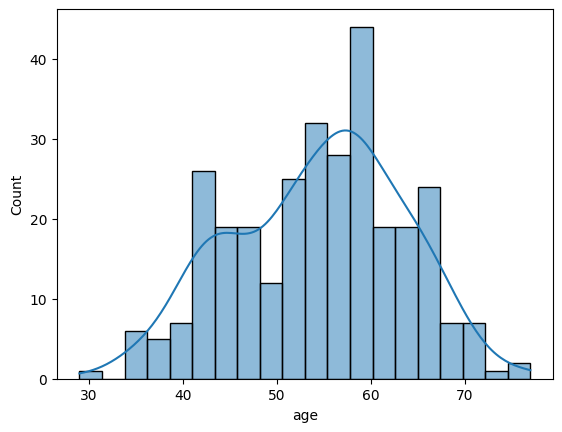

In [7]:
sns.histplot(df['age'],kde=True,bins=20)

<Axes: >

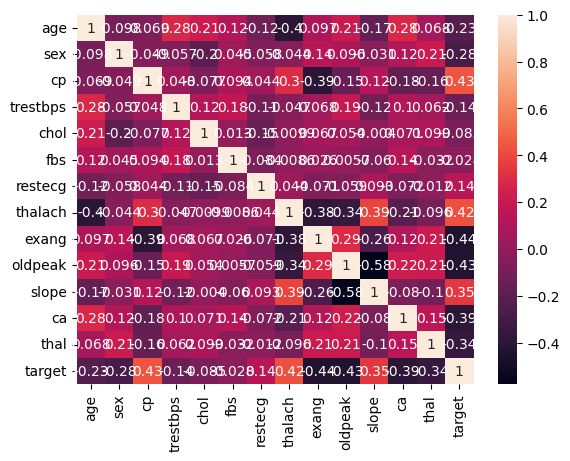

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [9]:
x = df.drop(['target'],axis = 1)
y = df['target']

In [10]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [11]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

## apply one-hot-encoding

In [12]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [13]:
one_hot_encoding = pd.get_dummies(x,columns=['age','trestbps','chol','thalach','oldpeak'],drop_first=True)

In [14]:
one_hot_encoding

,sex,cp,fbs,restecg,exang,slope,ca,thal,age_34,age_35,...,oldpeak_3.2,oldpeak_3.4,oldpeak_3.5,oldpeak_3.6,oldpeak_3.8,oldpeak_4.0,oldpeak_4.2,oldpeak_4.4,oldpeak_5.6,oldpeak_6.2
0,1,3,1,0,0,0,0,1,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,2,0,1,0,0,0,2,False,False,...,False,False,True,False,False,False,False,False,False,False
2,0,1,0,0,0,2,0,2,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,1,0,1,0,2,0,2,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,1,1,2,0,2,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0,0,0,1,1,1,0,3,False,False,...,False,False,False,False,False,False,False,False,False,False
299,1,3,0,1,0,1,0,3,False,False,...,False,False,False,False,False,False,False,False,False,False
300,1,0,1,1,0,1,2,3,False,False,...,False,True,False,False,False,False,False,False,False,False
301,1,0,0,1,1,1,1,3,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
one_hot_encoding.astype(int)

,sex,cp,fbs,restecg,exang,slope,ca,thal,age_34,age_35,...,oldpeak_3.2,oldpeak_3.4,oldpeak_3.5,oldpeak_3.6,oldpeak_3.8,oldpeak_4.0,oldpeak_4.2,oldpeak_4.4,oldpeak_5.6,oldpeak_6.2
0,1,3,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,1,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,1,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,1,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,1,2,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0,0,0,1,1,1,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
299,1,3,0,1,0,1,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
300,1,0,1,1,0,1,2,3,0,0,...,0,1,0,0,0,0,0,0,0,0
301,1,0,0,1,1,1,1,3,0,0,...,0,0,0,0,0,0,0,0,0,0


## label incoding 

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

columns = ['age','trestbps','chol','thalach','oldpeak']
xlabel = x.copy()
label_encoder = {}

for col in columns:
    le = LabelEncoder()
    xlabel[col] = le.fit_transform(xlabel[col].astype(str)) #convert to str into null values 
    
    label_encoder[col] = le
    


## doing standard scsler because some of values are not convert into numeric values

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
xlabel.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')

In [21]:
xlabel[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']] = scaler.fit_transform(xlabel[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']])

In [22]:
xlabel

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.966379,0.681005,1.973123,0.835229,-0.235035,2.394438,-1.005832,-0.122051,-0.696631,1.180512,-2.274579,-0.714429,-2.148873
1,-1.947181,0.681005,1.002577,-0.017831,0.181278,-0.417635,0.898962,1.548083,-0.696631,2.149612,-2.274579,-0.714429,-0.512922
2,-1.498941,-1.468418,0.032031,-0.017831,-0.989604,-0.417635,-1.005832,0.927747,-0.696631,0.405231,0.976352,-0.714429,-0.512922
3,0.181959,0.681005,0.032031,-0.776106,-0.156976,-0.417635,0.898962,1.166338,-0.696631,-0.176229,0.976352,-0.714429,-0.512922
4,0.294019,-1.468418,-0.938515,-0.776106,1.872553,-0.417635,0.898962,0.498284,1.435481,-0.370049,0.976352,-0.714429,-0.512922
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.294019,-1.468418,-0.938515,0.550876,-0.052898,-0.417635,0.898962,-1.362722,1.435481,-0.757689,-0.649113,-0.714429,1.123029
299,-1.050701,0.681005,1.973123,-1.344813,0.519533,-0.417635,0.898962,-0.933259,-0.696631,0.211411,-0.649113,-0.714429,1.123029
300,1.526679,0.681005,-0.938515,0.740445,-1.223780,2.394438,0.898962,-0.551514,-0.696631,2.052702,-0.649113,1.244593,1.123029
301,0.294019,0.681005,-0.938515,-0.017831,-1.874270,-0.417635,0.898962,-1.696749,1.435481,0.211411,-0.649113,0.265082,1.123029


## CREATING MODEL WITH THE HELP OF ONE-HOT-ENCOIDNG

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [24]:
X_train, X_test, y_train, y_test = train_test_split(one_hot_encoding, y, test_size=0.33, random_state=42)

In [25]:
Model = LinearRegression()
Model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## DOING PREDECTION

In [26]:
y_pred = Model.predict(X_test)

In [27]:
y_pred

array([ 2.15647360e-01,  9.68100695e-01,  9.33351191e-01,  2.30466584e-02,
        9.42885509e-01,  4.11709002e-01,  3.31700355e-01, -3.58871796e-01,
       -1.65747865e-01,  1.03984902e+00,  1.28282633e+00,  5.39236324e-01,
        1.33712766e+00,  1.25592182e-01,  9.94673103e-01,  1.20299902e+00,
        1.01015485e+00,  5.95057576e-02, -1.17746643e-01,  1.65621141e-01,
        6.99139774e-01,  6.58254897e-02,  1.03234685e+00,  2.33067932e-01,
        2.93625015e-01,  6.63106303e-01,  7.77943179e-01,  2.19445564e-01,
       -7.92139526e-02,  4.38440913e-01, -1.53234280e-01,  6.57198455e-01,
        2.94909406e-01,  5.91277214e-01,  1.10625322e+00,  8.90938644e-01,
        1.20451524e+00,  1.40112092e-03,  1.06126753e+00,  1.05606276e+00,
        3.73659222e-01,  5.72298248e-01,  1.04955948e+00,  1.23688704e+00,
        9.56039442e-02,  2.53893815e-01,  5.04557114e-01,  8.19760074e-01,
        2.49658465e-01, -2.23040292e-01, -8.55956425e-01,  9.08506253e-01,
        5.87205175e-01,  

In [28]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
163    1
155    1
97     1
68     1
229    0
Name: target, Length: 100, dtype: int64

In [29]:
r2 = r2_score(y_pred,y_test)

In [30]:
r2


-0.19740795446921489

In [31]:
n = X_test.shape[0]
m = X_test.shape[1]

adjusted_r2 = 1-((1-r2)*(n-1)/(n-m-1))

print("adjusted _r2 ",adjusted_r2)

adjusted _r2  1.427954467481777


In [32]:
Model2 = LinearRegression()
Model2.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = Model2.predict(X_test)

In [34]:
y_pred

array([ 2.15647360e-01,  9.68100695e-01,  9.33351191e-01,  2.30466584e-02,
        9.42885509e-01,  4.11709002e-01,  3.31700355e-01, -3.58871796e-01,
       -1.65747865e-01,  1.03984902e+00,  1.28282633e+00,  5.39236324e-01,
        1.33712766e+00,  1.25592182e-01,  9.94673103e-01,  1.20299902e+00,
        1.01015485e+00,  5.95057576e-02, -1.17746643e-01,  1.65621141e-01,
        6.99139774e-01,  6.58254897e-02,  1.03234685e+00,  2.33067932e-01,
        2.93625015e-01,  6.63106303e-01,  7.77943179e-01,  2.19445564e-01,
       -7.92139526e-02,  4.38440913e-01, -1.53234280e-01,  6.57198455e-01,
        2.94909406e-01,  5.91277214e-01,  1.10625322e+00,  8.90938644e-01,
        1.20451524e+00,  1.40112092e-03,  1.06126753e+00,  1.05606276e+00,
        3.73659222e-01,  5.72298248e-01,  1.04955948e+00,  1.23688704e+00,
        9.56039442e-02,  2.53893815e-01,  5.04557114e-01,  8.19760074e-01,
        2.49658465e-01, -2.23040292e-01, -8.55956425e-01,  9.08506253e-01,
        5.87205175e-01,  

In [35]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
163    1
155    1
97     1
68     1
229    0
Name: target, Length: 100, dtype: int64